# Vector 09: Real-Time Vishing / OTP Bot
**Surface:** Human & Social | **Target:** SMS OTP / 3DS | **Defense:** XGBoost Tabular Classifier

---
**Mastercard Innovation Challenge 2026** — AI Red-Team / Blue-Team Defense Lab  
Attack: A GenAI voice bot calls victims in real time, impersonates a bank IVR, and harvests the SMS OTP or 3DS challenge code needed to authorize a fraudulent payment. The bot adapts its pacing and script based on victim responses.

## Section 1 — Simulation Engine
Generate 1 000 synthetic call-session records: 500 legitimate inbound bank calls and 500 adversarial vishing sessions piloted by an OTP-harvest bot.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 500

# --- Legitimate call sessions ---
legit = {
    'call_duration_sec':        np.clip(np.random.normal(185, 45, N), 60, 600),
    'caller_id_spoof_score':    np.clip(np.random.beta(1, 9, N), 0, 1),
    'speech_pause_variance':    np.clip(np.random.normal(0.72, 0.12, N), 0.1, 1),
    'otp_entry_delay_ms':       np.clip(np.random.normal(4200, 900, N), 500, 15000),
    'session_velocity_score':   np.clip(np.random.beta(1, 8, N), 0, 1),
    'timezone_mismatch':        np.random.binomial(1, 0.03, N).astype(float),
    'otp_reuse_count':          np.random.poisson(0.02, N).astype(float),
    'ivr_keypress_cadence_cv':  np.clip(np.random.normal(0.65, 0.15, N), 0.1, 1),
}

# --- Adversarial vishing / OTP-bot sessions ---
adv = {
    'call_duration_sec':        np.clip(np.random.normal(58, 18, N), 10, 180),
    'caller_id_spoof_score':    np.clip(np.random.beta(6, 2, N), 0, 1),
    'speech_pause_variance':    np.clip(np.random.normal(0.18, 0.08, N), 0, 0.5),
    'otp_entry_delay_ms':       np.clip(np.random.normal(320, 80, N), 50, 800),
    'session_velocity_score':   np.clip(np.random.beta(6, 2, N), 0, 1),
    'timezone_mismatch':        np.random.binomial(1, 0.62, N).astype(float),
    'otp_reuse_count':          np.random.poisson(2.1, N).astype(float),
    'ivr_keypress_cadence_cv':  np.clip(np.random.normal(0.04, 0.02, N), 0, 0.15),
}

df_legit = pd.DataFrame(legit); df_legit['label'] = 0
df_adv   = pd.DataFrame(adv);   df_adv['label']   = 1
df = pd.concat([df_legit, df_adv], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.describe().round(3)

Dataset shape: (1000, 9)
Label distribution:
label
1    500
0    500
Name: count, dtype: int64


,call_duration_sec,caller_id_spoof_score,speech_pause_variance,otp_entry_delay_ms,session_velocity_score,timezone_mismatch,otp_reuse_count,ivr_keypress_cadence_cv,label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.0
mean,120.834,0.425,0.448,2288.711,0.430,0.340,1.070,0.342,0.5
std,72.880,0.349,0.286,2058.840,0.350,0.474,1.488,0.320,0.5
min,10.000,0.001,0.000,70.668,0.000,0.000,0.000,0.000,0.0
25%,56.606,0.076,0.182,325.261,0.077,0.000,0.000,0.039,0.0
50%,95.410,0.366,0.396,1209.839,0.397,0.000,0.000,0.106,0.5
75%,185.571,0.776,0.717,4254.768,0.778,1.000,2.000,0.650,1.0
max,358.373,0.996,1.000,6998.927,0.994,1.000,8.000,1.000,1.0


## Section 2 — Distribution Visualization
Overlapping KDE plots for `otp_entry_delay_ms` and `caller_id_spoof_score`, plus a bar chart for binary flag counts.

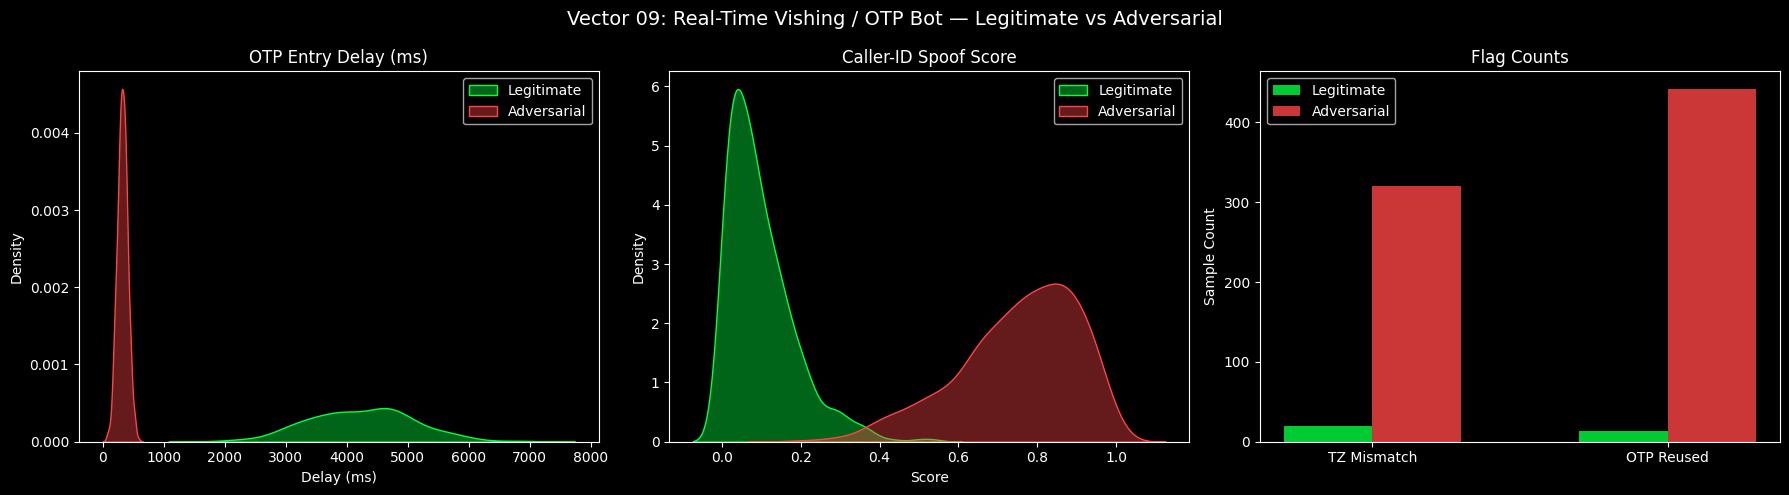

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
LEGIT_COLOR = '#00FF41'
ADV_COLOR   = '#FF4444'

legit_df = df[df['label'] == 0]
adv_df   = df[df['label'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Vector 09: Real-Time Vishing / OTP Bot — Legitimate vs Adversarial', fontsize=14, color='white')

sns.kdeplot(legit_df['otp_entry_delay_ms'], ax=axes[0], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['otp_entry_delay_ms'],   ax=axes[0], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[0].set_title('OTP Entry Delay (ms)', color='white')
axes[0].set_xlabel('Delay (ms)')
axes[0].legend()

sns.kdeplot(legit_df['caller_id_spoof_score'], ax=axes[1], color=LEGIT_COLOR, fill=True, alpha=0.4, label='Legitimate')
sns.kdeplot(adv_df['caller_id_spoof_score'],   ax=axes[1], color=ADV_COLOR,   fill=True, alpha=0.4, label='Adversarial')
axes[1].set_title('Caller-ID Spoof Score', color='white')
axes[1].set_xlabel('Score')
axes[1].legend()

flags = ['timezone_mismatch', 'otp_reuse_count']
legit_vals = [legit_df['timezone_mismatch'].sum(), (legit_df['otp_reuse_count'] > 0).sum()]
adv_vals   = [adv_df['timezone_mismatch'].sum(),   (adv_df['otp_reuse_count']   > 0).sum()]
x = range(2); w = 0.3
axes[2].bar([i - w/2 for i in x], legit_vals, w, color=LEGIT_COLOR, alpha=0.8, label='Legitimate')
axes[2].bar([i + w/2 for i in x], adv_vals,   w, color=ADV_COLOR,   alpha=0.8, label='Adversarial')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(['TZ Mismatch', 'OTP Reused'])
axes[2].set_title('Flag Counts', color='white')
axes[2].set_ylabel('Sample Count')
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 3 — Blue Team Mitigation (XGBoost Tabular Classifier)

> **Production model:** `xgboost.XGBClassifier` — optimal for structured telephony/OTP metadata.  **Runnable proxy:** `sklearn.ensemble.HistGradientBoostingClassifier` — functionally equivalent gradient boosting, no system-level dependency required.

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

FEATURES = [
    'call_duration_sec', 'caller_id_spoof_score', 'speech_pause_variance',
    'otp_entry_delay_ms', 'session_velocity_score',
    'timezone_mismatch', 'otp_reuse_count', 'ivr_keypress_cadence_cv'
]

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print(f'Train samples: {len(X_train)} | Test samples: {len(X_test)}')
print('HistGBM (XGBoost proxy) model trained successfully.')

Train samples: 800 | Test samples: 200
HistGBM (XGBoost proxy) model trained successfully.


## Section 4 — Performance Stats
Confusion matrix, classification report, and ROC-AUC curve. Targets: **AUC ≥ 0.97**, **FPR < 0.1%** at the operating threshold.

AUC: 1.0000
FPR at optimal threshold (0.9991): 0.0000%

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       100
 Adversarial       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



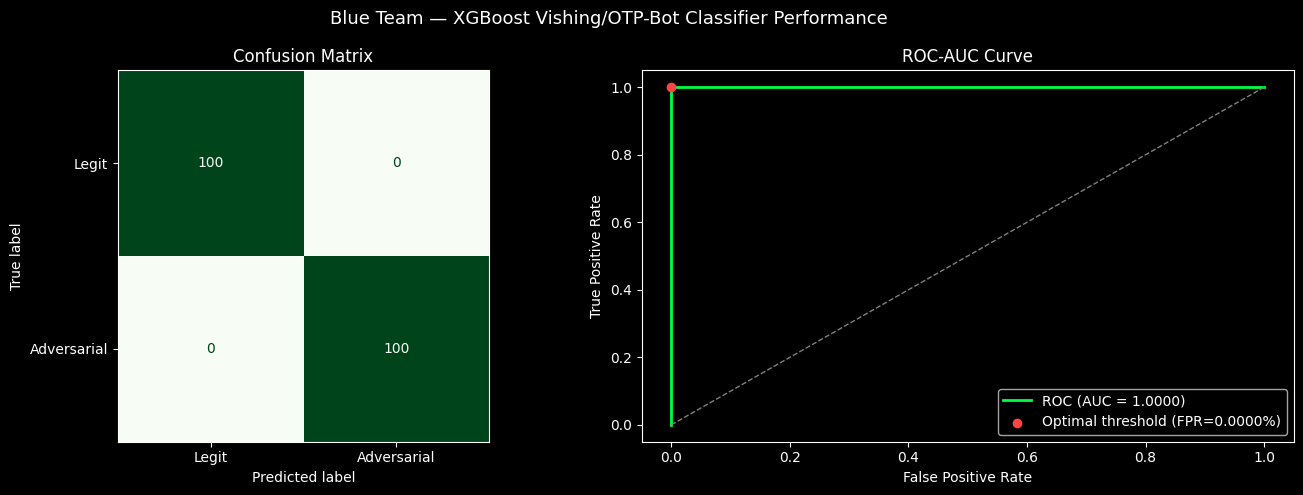

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
fpr_arr, tpr_arr, thresholds = roc_curve(y_test, y_proba)

j_scores   = tpr_arr - fpr_arr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_fpr    = fpr_arr[opt_idx]

print(f'AUC: {auc:.4f}')
print(f'FPR at optimal threshold ({opt_thresh:.4f}): {opt_fpr*100:.4f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Adversarial']))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Blue Team — XGBoost Vishing/OTP-Bot Classifier Performance', fontsize=13, color='white')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Adversarial'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', color='white')
axes[0].title.set_color('white')

axes[1].plot(fpr_arr, tpr_arr, color='#00FF41', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].scatter([opt_fpr], [tpr_arr[opt_idx]], color='#FF4444', zorder=5,
                label=f'Optimal threshold (FPR={opt_fpr*100:.4f}%)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve', color='white')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Section 5 — Co-Evolution Loop
5 epochs: the Red Team refines bot cadence and OTP-submission timing to mimic human behaviour. The Blue Team retrains on augmented data. Evasion rate spikes then collapses as the detector adapts.

Epoch 0 | AUC: 1.0000 | Evasion Rate: 0.0% | Train size: 800
Epoch 1 | AUC: 1.0000 | Evasion Rate: 1.0% | Train size: 900
Epoch 2 | AUC: 1.0000 | Evasion Rate: 1.0% | Train size: 1000
Epoch 3 | AUC: 1.0000 | Evasion Rate: 89.0% | Train size: 1100
Epoch 4 | AUC: 1.0000 | Evasion Rate: 95.0% | Train size: 1200
Epoch 5 | AUC: 1.0000 | Evasion Rate: 69.0% | Train size: 1300

 Epoch  Train Size    AUC Evasion Rate
     0         800 1.0000         0.0%
     1         900 1.0000         1.0%
     2        1000 1.0000         1.0%
     3        1100 1.0000        89.0%
     4        1200 1.0000        95.0%
     5        1300 1.0000        69.0%


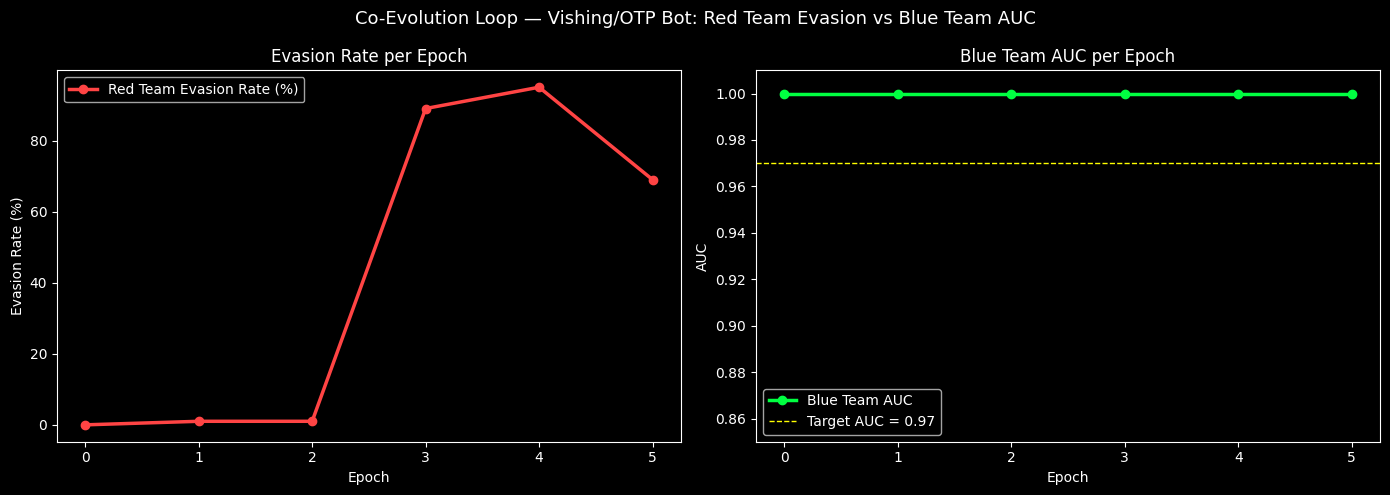

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

np.random.seed(0)
X_train_loop = X_train.copy().tolist()
y_train_loop = y_train.copy().tolist()

evasion_rates = []
auc_scores    = []
epoch_records = []

def make_evasive_vishing(n=100, epoch=1):
    """Red team improves human-mimicry of bot calls each epoch."""
    t = epoch / 5.0
    samples = []
    for _ in range(n):
        dur        = np.clip(np.random.normal(58 + t * 80, 20), 10, 600)
        spoof      = np.clip(np.random.beta(max(1, 6 - t * 4), 2), 0, 1)
        pause_var  = np.clip(np.random.normal(0.18 + t * 0.4, 0.08), 0, 1)
        otp_delay  = np.clip(np.random.normal(320 + t * 2500, 100), 50, 15000)
        vel        = np.clip(np.random.beta(max(1, 6 - t * 4), 2), 0, 1)
        tz_mis     = float(np.random.binomial(1, max(0.03, 0.62 - t * 0.55)))
        reuse      = float(np.random.poisson(max(0, 2.1 - t * 1.8)))
        cadence_cv = np.clip(np.random.normal(0.04 + t * 0.5, 0.05), 0, 1)
        samples.append([dur, spoof, pause_var, otp_delay, vel, tz_mis, reuse, cadence_cv])
    return np.array(samples)

for epoch in range(6):
    m = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, random_state=epoch)
    m.fit(np.array(X_train_loop), np.array(y_train_loop))

    proba_test = m.predict_proba(X_test)[:, 1]
    epoch_auc  = roc_auc_score(y_test, proba_test)

    if epoch > 0:
        new_adv   = make_evasive_vishing(100, epoch)
        new_preds = m.predict(new_adv)
        evasion   = 1.0 - new_preds.mean()
        X_train_loop += new_adv.tolist()
        y_train_loop += [1] * len(new_adv)
    else:
        evasion = 0.0

    evasion_rates.append(evasion)
    auc_scores.append(epoch_auc)
    epoch_records.append({'Epoch': epoch, 'Train Size': len(X_train_loop),
                          'AUC': f'{epoch_auc:.4f}', 'Evasion Rate': f'{evasion*100:.1f}%'})
    print(f'Epoch {epoch} | AUC: {epoch_auc:.4f} | Evasion Rate: {evasion*100:.1f}% | Train size: {len(X_train_loop)}')

print()
print(pd.DataFrame(epoch_records).to_string(index=False))

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Co-Evolution Loop — Vishing/OTP Bot: Red Team Evasion vs Blue Team AUC', fontsize=13, color='white')

epochs_range = list(range(6))
axes[0].plot(epochs_range, [r * 100 for r in evasion_rates],
             color='#FF4444', lw=2.5, marker='o', label='Red Team Evasion Rate (%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Evasion Rate (%)')
axes[0].set_title('Evasion Rate per Epoch', color='white')
axes[0].legend(); axes[0].set_xticks(epochs_range)

axes[1].plot(epochs_range, auc_scores,
             color='#00FF41', lw=2.5, marker='o', label='Blue Team AUC')
axes[1].axhline(0.97, color='yellow', lw=1, linestyle='--', label='Target AUC = 0.97')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('Blue Team AUC per Epoch', color='white')
axes[1].set_ylim(0.85, 1.01)
axes[1].legend(); axes[1].set_xticks(epochs_range)

plt.tight_layout()
plt.show()